In [1]:
library(class)
library(ggplot2)
library(caret)
library(pROC)
library(repr)
options(repr.plot.width = 9, repr.plot.height = 6)

data(iris)

Loading required package: lattice

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [2]:
set.seed(123)
train.idx <- sample(nrow(iris), size = 0.8 * nrow(iris), replace = FALSE)
tr <- iris[train.idx, ]    # 120 rows
nw <- iris[-train.idx, ]   # 30 rows, no overlap with training

nrow(tr); nrow(nw)
length(intersect(rownames(tr), rownames(nw)))  # should be 0

[1] 120

[1] 30

[1] 0

            Actual
Predicted    setosa versicolor virginica
  setosa         10          0         0
  versicolor      0         14         0
  virginica       0          1         5

[1] 0.9666667

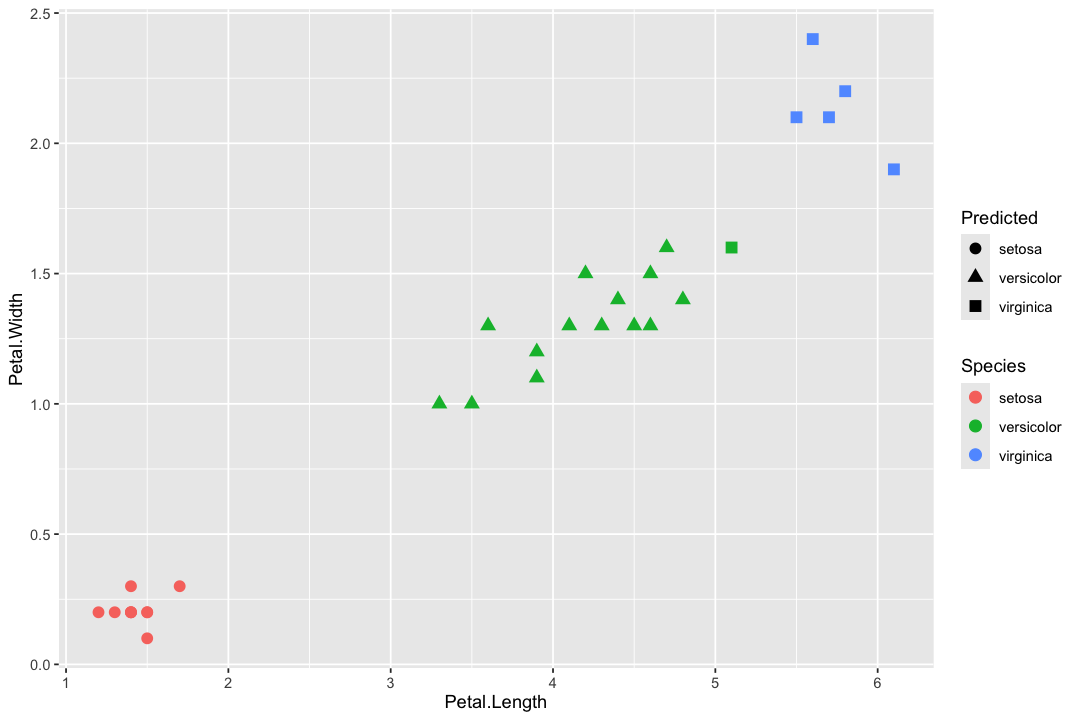

In [3]:
# A common rule of thumb is k ~ sqrt(n) (about 11 here). Use whatever your group agrees on.
num.neighbor <- 5

knn.result <- knn(tr[, -5], nw[, -5], tr$Species, k = num.neighbor)

# confusion matrix
table(Predicted = knn.result, Actual = nw$Species)

# accuracy
mean(knn.result == nw$Species)

# visual check of predictions vs. truth
ggplot(nw, aes(Petal.Length, Petal.Width, color = Species, shape = knn.result)) +
  geom_point(size = 3) +
  labs(shape = "Predicted")

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28

[1] 14

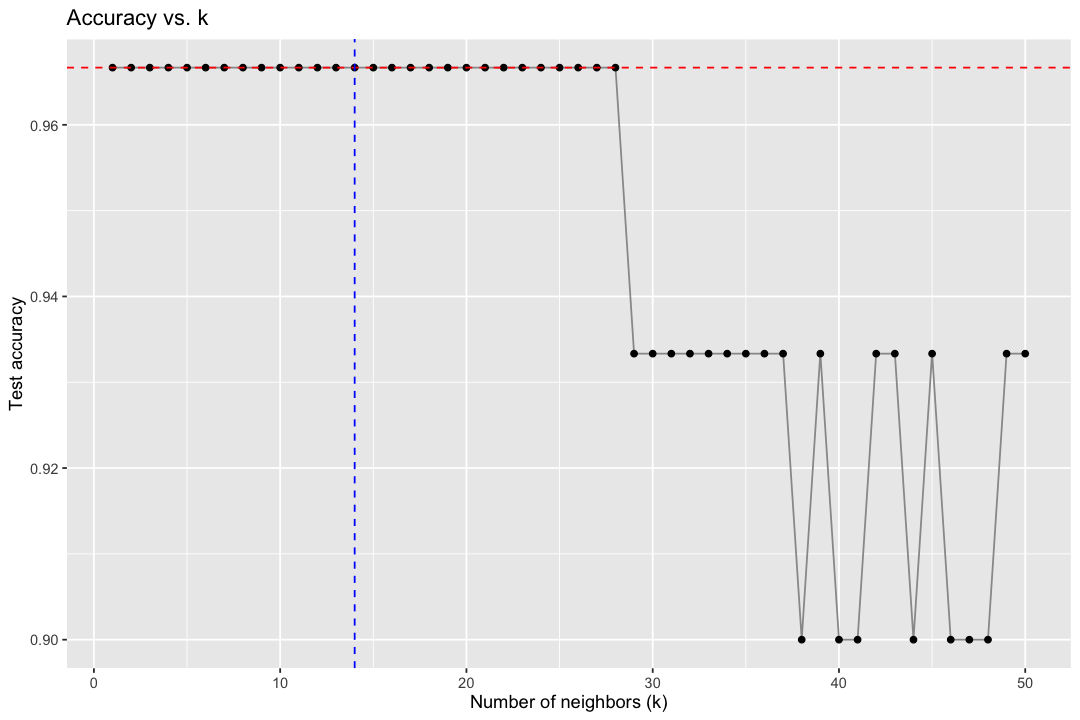

In [4]:
max.k <- 50   # k can't sensibly exceed the training size; 50 is plenty to see the trend
accuracy <- numeric(max.k)

for (i in 1:max.k) {
  pred <- knn(tr[, -5], nw[, -5], tr$Species, k = i)
  accuracy[i] <- mean(pred == nw$Species)
}

acc.df <- data.frame(neighbors = 1:max.k, accuracy = accuracy)

# Several k values usually tie for the max. Take the middle of the tied range for stability.
best.ks <- acc.df$neighbors[acc.df$accuracy == max(acc.df$accuracy)]
optimal.k <- best.ks[ceiling(length(best.ks) / 2)]
best.ks; optimal.k

ggplot(acc.df, aes(neighbors, accuracy)) +
  geom_line(color = "grey60") +
  geom_point() +
  geom_hline(yintercept = max(acc.df$accuracy), color = "red", linetype = "dashed") +
  geom_vline(xintercept = optimal.k, color = "blue", linetype = "dashed") +
  labs(title = "Accuracy vs. k", x = "Number of neighbors (k)", y = "Test accuracy")

Multi-class area under the curve: 1

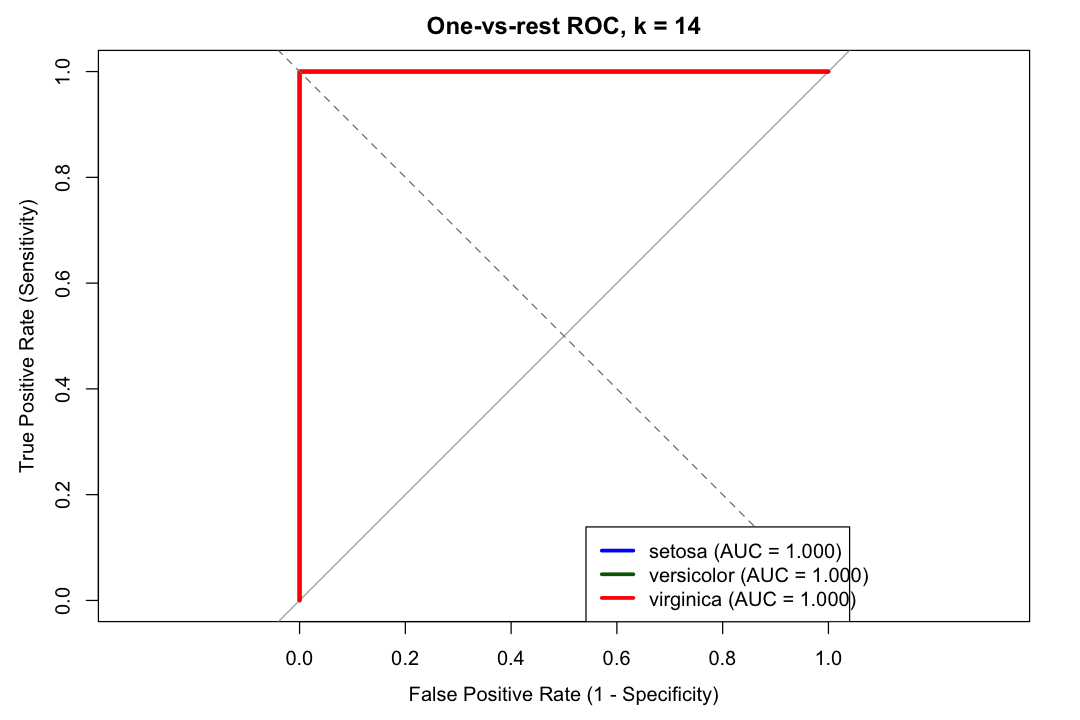

In [5]:
# Class probabilities from kNN (proportion of the k neighbors in each class)
fit   <- knn3(Species ~ ., data = tr, k = optimal.k)
probs <- predict(fit, nw, type = "prob")

# Multiclass AUC (average of pairwise AUCs)
mc.roc <- multiclass.roc(nw$Species, probs, quiet = TRUE)
auc(mc.roc)

# One-vs-rest ROC curve for each species
classes <- levels(nw$Species)
cols    <- c("blue", "darkgreen", "red")

roc.list <- lapply(classes, function(cl) {
  roc(nw$Species == cl, probs[, cl], levels = c(FALSE, TRUE),
      direction = "<", quiet = TRUE)
})

plot(roc.list[[1]], col = cols[1], lwd = 3, legacy.axes = TRUE,
     xlab = "False Positive Rate (1 - Specificity)",
     ylab = "True Positive Rate (Sensitivity)",
     main = paste("One-vs-rest ROC, k =", optimal.k))
for (j in 2:3) lines(roc.list[[j]], col = cols[j], lwd = 3)
abline(a = 0, b = 1, lty = 2, col = "grey50")

aucs <- sapply(roc.list, auc)
legend("bottomright", lwd = 3, col = cols,
       legend = sprintf("%s (AUC = %.3f)", classes, aucs))